Text(0.5, 0.5, '$y$')

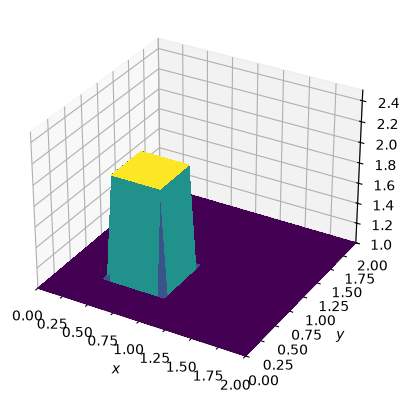

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
from IPython.display import clear_output

nx = 31
ny = 31
nt = 50
nu = 0.05

dx = 2 / (nx - 1)
dy = 2 / (ny - 1)

sigma = 0.25
dt = sigma * dx * dy / nu

x = np.linspace(0, 2, nx)
y = np.linspace(0, 2, ny)

u = np.ones((ny, nx))

u[int(0.5 / dy):int(1.0 / dy),int(0.5 / dx):int(1.0 / dx)] = 2

fig = plt.figure()
ax = fig.add_subplot(projection='3d')
X, Y = np.meshgrid(x, y)
surf = ax.plot_surface(X, Y, u, rstride=1, cstride=1, cmap=cm.viridis, linewidth=0, antialiased=False)

ax.set_xlim(0, 2)
ax.set_ylim(0, 2)
ax.set_zlim(1, 2.5)

ax.set_xlabel('$x$')
ax.set_ylabel('$y$')

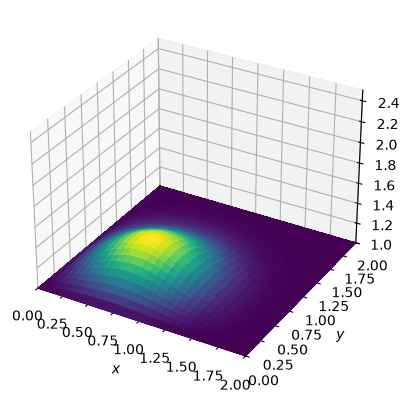

In [2]:
for n in range(nt):
    un = u.copy()

    x_term = nu * dt / dx**2 * (un[1:-1, 2:] - 2 * un[1:-1, 1:-1] + un[1:-1, :-2])
    y_term = nu * dt / dy**2 * (un[2:, 1:-1] - 2 * un[1:-1, 1:-1] + un[:-2, 1:-1])
    u[1:-1, 1:-1] = un[1:-1, 1:-1] + x_term + y_term

    u[0, :] = 1
    u[-1, :] = 1
    u[:, 0] = 1
    u[:, -1] = 1

    clear_output(True)

    fig = plt.figure()
    ax = fig.add_subplot(projection='3d')
    X, Y = np.meshgrid(x, y)
    surf = ax.plot_surface(X, Y, u, rstride=1, cstride=1, cmap=cm.viridis, linewidth=0, antialiased=False)

    ax.set_xlim(0, 2)
    ax.set_ylim(0, 2)
    ax.set_zlim(1, 2.5)

    ax.set_xlabel('$x$')
    ax.set_ylabel('$y$')

    plt.pause(0.0001)